In [1]:
# Import Necessary Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the Dataset

dataset = pd.read_csv("building-price-prediction.csv")
dataset

,plot_size,bedrooms,distance_to_center_km,age_of_building,plot_price
0,152,4,2.4,25,588325
1,229,1,19.8,22,705785
2,142,3,15.7,27,471414
3,64,5,4.8,24,298531
4,156,3,1.1,6,603728
5,121,5,16.5,29,432816
6,238,1,14.4,0,789246
7,70,2,14.9,0,220670
8,152,4,15.7,24,537402
9,171,1,2.4,26,573967


In [3]:
# Select Features and Display the First 5 Rows

features = dataset[["plot_size", "bedrooms", "distance_to_center_km", "age_of_building"]]
features.head(5)

,plot_size,bedrooms,distance_to_center_km,age_of_building
0,152,4,2.4,25
1,229,1,19.8,22
2,142,3,15.7,27
3,64,5,4.8,24
4,156,3,1.1,6


In [4]:
# Select Labels and Display the Last 5 Rows

labels = dataset[["plot_price"]]
labels.tail(5)

,plot_price
47,781685
48,865899
49,314107
50,579200
51,445013


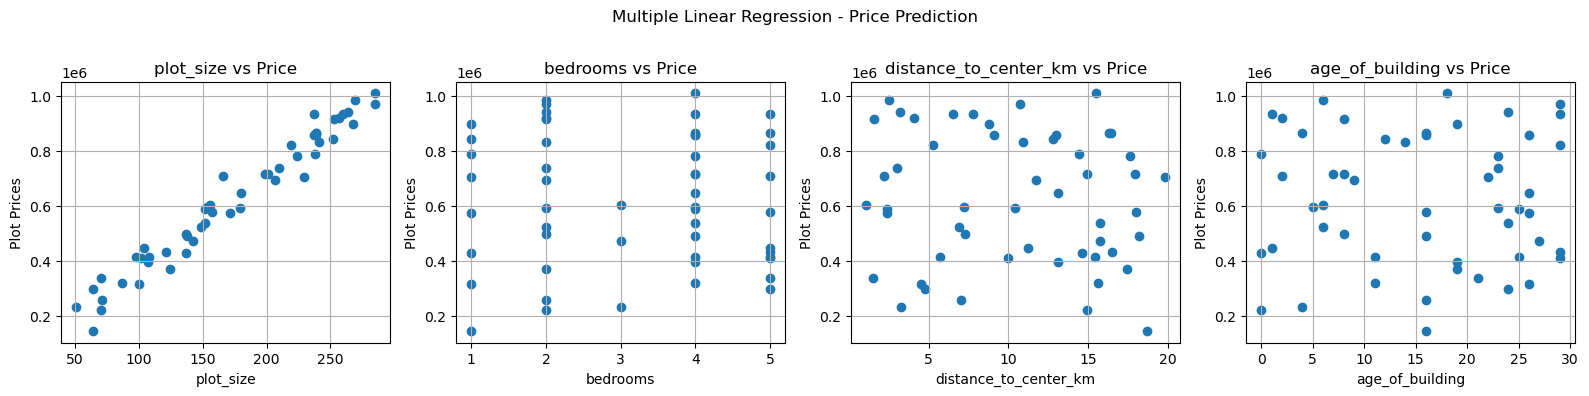

In [5]:
# Visualize the Relationship between Features and Labels

# Create a figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. Plot Size vs Price
axes[0].scatter(dataset["plot_size"], dataset["plot_price"])
axes[0].set_xlabel("plot_size")
axes[0].set_ylabel("Plot Prices")
axes[0].set_title("plot_size vs Price")
axes[0].grid(True)

# 2. Bedrooms vs Price
axes[1].scatter(dataset["bedrooms"], dataset["plot_price"])
axes[1].set_xlabel("bedrooms")
axes[1].set_ylabel("Plot Prices")
axes[1].set_title("bedrooms vs Price")
axes[1].grid(True)

# 3. Distance to Center vs Price
axes[2].scatter(dataset["distance_to_center_km"], dataset["plot_price"])
axes[2].set_xlabel("distance_to_center_km")
axes[2].set_ylabel("Plot Prices")
axes[2].set_title("distance_to_center_km vs Price")
axes[2].grid(True)

# 4. Age of Building vs Price
axes[3].scatter(dataset["age_of_building"], dataset["plot_price"])
axes[3].set_xlabel("age_of_building")
axes[3].set_ylabel("Plot Prices")
axes[3].set_title("age_of_building vs Price")
axes[3].grid(True)

# Display the Plots
plt.suptitle("Multiple Linear Regression - Price Prediction")
plt.tight_layout()
plt.show()

In [6]:
# Define the Loss Function

# Parameters: weights (m1, m2, m3, m4) or (w1, w2, w3, w4), dataset (building-price-prediction.csv), bias (y-intercept)
def calculate_loss(weights, dataset, bias):

    # Create a total error variable to store the total error for all datapoints    
    total_error = 0

    # Iterate through all the datapoints/row
    for datapoint in range(0, len(dataset)):

        # Get each value separately from the row being iterated
        x1 = dataset.iloc[datapoint]["plot_size"]
        x2 = dataset.iloc[datapoint]["bedrooms"]
        x3 = dataset.iloc[datapoint]["distance_to_center_km"]
        x4 = dataset.iloc[datapoint]["age_of_building"]
        y  = dataset.iloc[datapoint]["plot_price"]

        # Calculate mx
        w1, w2, w3, w4 = weights
        mx = (x1*w1)+(x2*w2)+(x3*w3)+(x4*w4)
    
        # Caluclate mx+c
        prediction = mx+bias

        # Calculate error for single datapoint
        single_error = (y - prediction)**2

        # Add the error with total error
        total_error = total_error + single_error

    # Calculate the final loss by dividing the total error by the number of datapoints in the dataset
    final_loss = total_error / len(dataset)

    # Return the final loss
    return final_loss

In [7]:
# Test the Loss Function with Different Weights and Bias Values

print(f"weights=[-10,-10,-10,-10],     c=0,   loss={calculate_loss([-10, -10, -10, -10],    dataset, 0)/1000000000:.2f} Billion")
print(f"weights=[10,10,10,10],         c=0,   loss={calculate_loss([10, 10, 10, 10],    dataset, 0)/1000000000:.2f} Billion")
print(f"weights=[3000,80,100,200],     c=0,   loss={calculate_loss([3000,80,100,200], dataset, 0)/1000000000:.2f} Billion")

weights=[-10,-10,-10,-10],     c=0,   loss=447.46 Billion
weights=[10,10,10,10],         c=0,   loss=441.76 Billion
weights=[3000,80,100,200],     c=0,   loss=12.13 Billion


In [8]:
# Define the Derivatives Function
def derivatives(weights, c, data, lr):

    # Initialize the gradients for weights and bias to zero
    w0_grad = 0
    w1_grad = 0
    w2_grad = 0
    w3_grad = 0
    c_grad  = 0

    # Get the number of datapoints in the dataset
    N       = len(data)

    # Iterate through all the datapoints/row
    for i in range(N):

        # Get each value separately from the row being iterated
        plot_size             = data.iloc[i]["plot_size"]
        bedrooms              = data.iloc[i]["bedrooms"]
        distance_to_center_km = data.iloc[i]["distance_to_center_km"]
        age_of_building       = data.iloc[i]["age_of_building"]
        y                     = data.iloc[i]["plot_price"]

        # Calculate mx
        mx = (weights[0] * plot_size) + (weights[1] * bedrooms) + (weights[2] * distance_to_center_km) + (weights[3] * age_of_building)

        # Calculate mx+c
        prediction = mx + c

        # Calculate the error for the current datapoint
        error      = y - prediction

        # Update the gradients for weights
        w0_grad = w0_grad + (-2 * plot_size             * error)
        w1_grad = w1_grad + (-2 * bedrooms              * error)
        w2_grad = w2_grad + (-2 * distance_to_center_km * error)
        w3_grad = w3_grad + (-2 * age_of_building       * error)

        # Update the gradient for bias
        c_grad  = c_grad  + (-2 * error)

    # Update the weights and bias using the calculated gradients and learning rate
    weights[0] = weights[0] - (lr * w0_grad / N)
    weights[1] = weights[1] - (lr * w1_grad / N)
    weights[2] = weights[2] - (lr * w2_grad / N)
    weights[3] = weights[3] - (lr * w3_grad / N)
    c          = c          - (lr * c_grad   / N)

    # Return the updated weights and bias
    return weights, c

In [ ]:
# Hyperparameters

# Initialize weights to zero
w0 = 0
w1 = 0
w2 = 0
w3 = 0

# Create a list of weights for easier manipulation
weights = [w0, w1, w2, w3]

# Initialize bias to zero
bias  = 0

# Set the learning rate
lr = 0.00001

# Set the number of epochs for training
epochs = 5000

# Print initial values - before training: weights, bias, and loss
print(f"Before training: w0={w0}, w1={w1}, w2={w2}, w3={w3}, c={bias}, Loss={calculate_loss(weights, dataset, bias)/100000000:.2f} Million")

# Train the Model
for epoch in range(epochs):

    # Update weights and bias using the derivatives function
    weights, bias = derivatives(weights, bias, dataset, lr)

    # Calculate the loss using the updated weights and bias
    loss = calculate_loss(weights, dataset, bias)

    # Print the weights, bias, and loss every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d}:\tw0={round(weights[0],2)},\tw1={round(weights[1],2)},\tw2={round(weights[2],2)},\tw3={round(weights[3],2)},\tc={c:.2f},\tLoss={loss/100000000:.2f} Million")

# After training: weights, bias, and loss
print(f"After training:\tw0={round(weights[0],2)},\tw1={round(weights[1],2)},\tw2={round(weights[2],2)},\tw3={round(weights[3],2)},\tc={bias:.2f},\tLoss={loss/100000000:.2f} Million")

Before training: w0=0, w1=0, w2=0, w3=0, c=0, Loss=4446.05 Million
Epoch   0:	w0=2488.51,	w1=39.1,	w2=126.35,	w3=192.73,	c=12.48,	Loss=404.04 Million
Epoch 100:	w0=3538.18,	w1=173.53,	w2=-16.56,	w3=207.34,	c=0.07,	Loss=21.04 Million
Epoch 200:	w0=3549.19,	w1=294.46,	w2=-194.7,	w3=160.31,	c=0.08,	Loss=20.55 Million
Epoch 300:	w0=3558.24,	w1=417.15,	w2=-356.91,	w3=127.53,	c=0.08,	Loss=20.13 Million
Epoch 400:	w0=3565.72,	w1=541.19,	w2=-505.07,	w3=105.41,	c=0.08,	Loss=19.75 Million
Epoch 500:	w0=3571.92,	w1=666.26,	w2=-640.83,	w3=91.18,	c=0.09,	Loss=19.41 Million
Epoch 600:	w0=3577.1,	w1=792.08,	w2=-765.53,	w3=82.71,	c=0.09,	Loss=19.09 Million
Epoch 700:	w0=3581.43,	w1=918.44,	w2=-880.37,	w3=78.39,	c=0.09,	Loss=18.80 Million
Epoch 800:	w0=3585.08,	w1=1045.16,	w2=-986.36,	w3=76.99,	c=0.09,	Loss=18.53 Million
Epoch 900:	w0=3588.16,	w1=1172.1,	w2=-1084.38,	w3=77.57,	c=0.10,	Loss=18.27 Million
Epoch 1000:	w0=3590.76,	w1=1299.13,	w2=-1175.2,	w3=79.43,	c=0.10,	Loss=18.03 Million
Epoch 1100:	w0=

In [ ]:
# Read user input for plot size, number of bedrooms, distance to center, and age of building
plot_size = int(input("Enter plot size: "))
bedrooms  = int(input("Enter number of bedrooms: "))
distance  = float(input("Enter distance to center (km): "))
age       = float(input("Enter age of building (years): "))

# Calculate the predicted price using the trained weights and bias
prediction = (weights[0] * plot_size) + (weights[1] * bedrooms) + (weights[2] * distance) + (weights[3] * age) + bias

# Print the predicted price rounded to the nearest whole number
print("The ideal price for your plot is:", round(prediction))

The ideal price for your plot is: 3646996
